In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/iris/Iris.csv
/kaggle/input/datasets/uciml/iris/database.sqlite


In [2]:
# Task 6: K-Nearest Neighbors (KNN) Classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/uciml/iris


In [4]:
df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Inspect the dataset

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Species"].value_counts())

Shape: (150, 6)

Columns:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Target distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [6]:
# Prepare features and target

X = df.drop(["Id", "Species"], axis=1)
y = df["Species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [7]:
# Encode target labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Encoded classes:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


In [8]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [9]:
# Normalize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features normalized successfully!")

Features normalized successfully!


In [10]:
# Test different K values

k_values = [1, 3, 5, 7, 9, 11, 13, 15]

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    accuracies.append(accuracy)
    
    print(f"K = {k:2d} | Accuracy = {accuracy:.4f}")

K =  1 | Accuracy = 0.9667
K =  3 | Accuracy = 0.9333
K =  5 | Accuracy = 0.9333
K =  7 | Accuracy = 0.9667
K =  9 | Accuracy = 0.9667
K = 11 | Accuracy = 0.9667
K = 13 | Accuracy = 0.9667
K = 15 | Accuracy = 0.9667


In [11]:
# Find the best K value

best_index = np.argmax(accuracies)

best_k = k_values[best_index]
best_accuracy = accuracies[best_index]

print(f"Best K: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K: 1
Best Accuracy: 0.9667


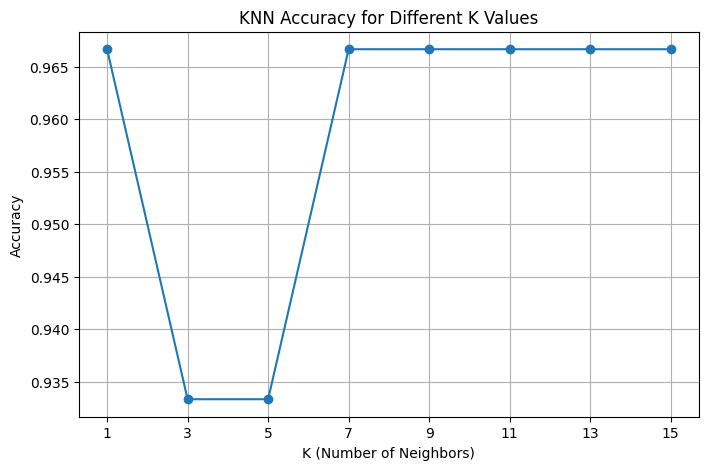

In [12]:
# Plot K values vs accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(k_values)
plt.grid()

plt.show()

In [13]:
# Train final KNN model using the best K

knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"Final KNN Accuracy (K={best_k}): {final_accuracy:.4f}")

Final KNN Accuracy (K=1): 0.9667


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


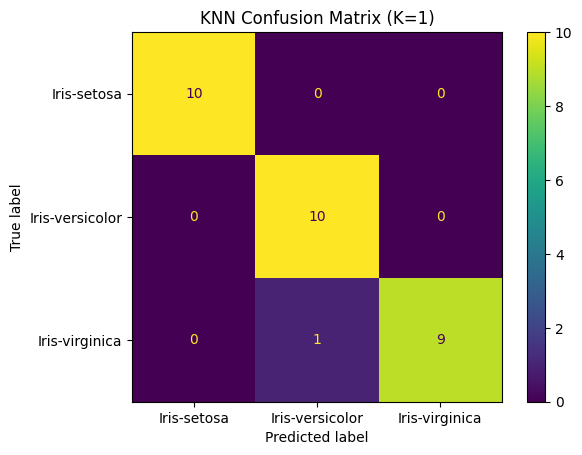

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()

In [15]:
# K values and their accuracies

k_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": accuracies
})

display(k_results)

,K,Accuracy
0,1,0.966667
1,3,0.933333
2,5,0.933333
3,7,0.966667
4,9,0.966667
5,11,0.966667
6,13,0.966667
7,15,0.966667


In [16]:
# Prepare two features for decision boundary visualization

X_2d = df[["PetalLengthCm", "PetalWidthCm"]]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Normalize the two features
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train KNN using best K
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d_scaled, y_train_2d)

print("2D KNN model trained for decision boundary visualization.")

2D KNN model trained for decision boundary visualization.


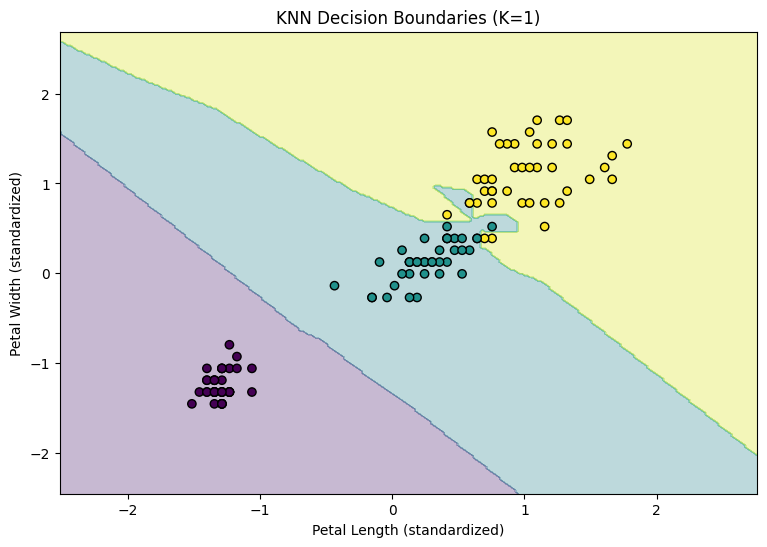

In [17]:
# Create decision boundary

x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = knn_2d.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    edgecolor="k"
)

plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.title(f"KNN Decision Boundaries (K={best_k})")

plt.show()

# Conclusion

In this task, K-Nearest Neighbors (KNN) was implemented for classification using the Iris dataset.

The dataset was divided into training and testing sets, and the features were normalized using StandardScaler because KNN relies on distance calculations.

Different values of K were tested to study their effect on classification accuracy. The best K value was selected based on test accuracy.

The final KNN model was evaluated using accuracy and a confusion matrix.

A decision boundary was also visualized using Petal Length and Petal Width to demonstrate how KNN separates different Iris classes in a two-dimensional feature space.

Overall, the experiment demonstrated instance-based learning, distance-based classification, K selection, feature normalization, model evaluation, and decision boundary visualization.